In [0]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('la_sales.sqlite')


In [0]:
import pandas as pd

# Use the full path to the file from your Volume
correct_path = "/Volumes/workspace/default/project_files/LA_Retail_Sales.csv"

sales_df = pd.read_csv(correct_path)

display(sales_df.head())

store_id,store_name,product_category,date,Unit sales,DOLLAR SALES,store_zip,promotion_flag
LA002,Store_2,Household,9/1/24,16.0,96.28,90004,true
LA001,Store_1,Beverages,9/1/24,14.0,86.63,90004,true
LA004,Store_4,Produce,9/15/24,18.0,298.26,90003,true
LA003,Store_3,Household,9/7/24,7.0,25.69,90001,true
LA008,Store_8,Beverages,9/18/24,25.0,85.46,90005,false


In [0]:
sales_df.info

<bound method DataFrame.info of     store_id store_name  ... store_zip promotion_flag
0      LA002    Store_2  ...     90004           True
1      LA001    Store_1  ...     90004           True
2      LA004    Store_4  ...     90003           True
3      LA003    Store_3  ...     90001           True
4      LA008    Store_8  ...     90005          False
..       ...        ...  ...       ...            ...
745    LA010   Store_10  ...     90005           True
746    LA008    Store_8  ...     90003          False
747    LA004    Store_4  ...     900XX          False
748    LA009    Store_9  ...     90004          False
749    LA010   Store_10  ...     90003          False

[750 rows x 8 columns]>

In [0]:
import glob
full_path_pattern = "/Volumes/workspace/default/project_files/LA_Retail_Sales_By_Day/*.csv"

file_paths = glob.glob(full_path_pattern)

# This will now show the list of files
file_paths
sales_df=pd.concat([pd.read_csv(fp) for fp in file_paths],ignore_index=True)
sales_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   store_id          750 non-null    object 
 1   store_name        750 non-null    object 
 2   product_category  750 non-null    object 
 3   date              750 non-null    object 
 4   unit_sales        745 non-null    float64
 5   dollar_sales      743 non-null    float64
 6   store_zip         750 non-null    object 
 7   promotion_flag    750 non-null    bool   
dtypes: bool(1), float64(2), object(5)
memory usage: 41.9+ KB


In [0]:
sales_df=pd.DataFrame()
for day in range(1,6):
    day_df=pd.read_csv(f"/Volumes/workspace/default/project_files/LA_Retail_Sales_By_Day/sales_2024-09-{day:02d}.csv")
    sales_df=pd.concat([sales_df,day_df])
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120 entries, 0 to 22
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   store_id          120 non-null    object 
 1   store_name        120 non-null    object 
 2   product_category  120 non-null    object 
 3   date              120 non-null    object 
 4   unit_sales        120 non-null    float64
 5   dollar_sales      120 non-null    float64
 6   store_zip         120 non-null    object 
 7   promotion_flag    120 non-null    bool   
dtypes: bool(1), float64(2), object(5)
memory usage: 7.6+ KB


In [0]:
#Reading json file
sales_df=pd.read_json("/Volumes/workspace/default/project_files/LA_Retail_Sales.json",lines=True)
sales_df

,store_id,store_name,product_category,date,unit_sales,dollar_sales,store_zip,promotion_flag
0,LA002,Store_2,Household,2024-09-01,16.0,96.28,90004,True
1,LA001,Store_1,Beverages,2024-09-01,14.0,86.63,90004,True
2,LA004,Store_4,Produce,2024-09-15,18.0,298.26,90003,True
3,LA003,Store_3,Household,2024-09-07,7.0,25.69,90001,True
4,LA008,Store_8,Beverages,2024-09-18,25.0,85.46,90005,False
...,...,...,...,...,...,...,...,...
745,LA010,Store_10,Beverages,2024-09-24,46.0,790.99,90005,True
746,LA008,Store_8,Snacks,2024-09-14,23.0,375.40,90003,False
747,LA004,Store_4,Personal Care,2024-09-14,17.0,225.24,900XX,False
748,LA009,Store_9,Snacks,2024-09-28,37.0,406.47,90004,False


In [0]:
#Reading parquet file
sales_df=pd.read_parquet("/Volumes/workspace/default/project_files/LA_Retail_Sales.parquet")
sales_df

,store_id,store_name,product_category,date,unit_sales,dollar_sales,store_zip,promotion_flag
0,LA002,Store_2,Household,2024-09-01,16.0,96.28,90004,True
1,LA001,Store_1,Beverages,2024-09-01,14.0,86.63,90004,True
2,LA004,Store_4,Produce,2024-09-15,18.0,298.26,90003,True
3,LA003,Store_3,Household,2024-09-07,7.0,25.69,90001,True
4,LA008,Store_8,Beverages,2024-09-18,25.0,85.46,90005,False
...,...,...,...,...,...,...,...,...
745,LA010,Store_10,Beverages,2024-09-24,46.0,790.99,90005,True
746,LA008,Store_8,Snacks,2024-09-14,23.0,375.40,90003,False
747,LA004,Store_4,Personal Care,2024-09-14,17.0,225.24,900XX,False
748,LA009,Store_9,Snacks,2024-09-28,37.0,406.47,90004,False


In [0]:
# First, convert your pandas DataFrame to a Spark DataFrame
spark_df = spark.createDataFrame(sales_df)

# Now, save the Spark DataFrame as a permanent SQL table
# This will overwrite the table if it already exists
spark_df.write.mode("overwrite").saveAsTable("la_sales_data_cleaned")

print("Table 'la_sales_data_cleaned' created successfully!")

Table 'la_sales_data_cleaned' created successfully!


In [0]:
# The SQL query to select all data from your table
sql_query = "SELECT * FROM la_sales_data_cleaned"

# Run the query using spark.sql()
sales_table_df = spark.sql(sql_query)

# Display the first few rows of the new DataFrame
display(sales_table_df.head())


Row(store_id='LA002', store_name='Store_2', product_category='Household', date=datetime.datetime(2024, 9, 1, 0, 0), unit_sales=16.0, dollar_sales=96.28, store_zip='90004', promotion_flag=True)

<Axes: xlabel='store_id'>

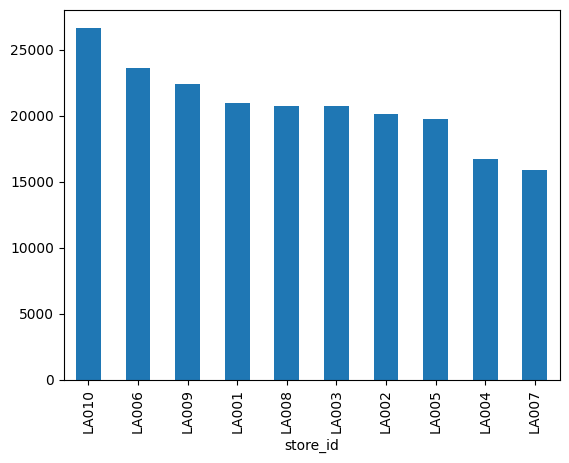

In [0]:
sql_query = (
    "SELECT store_id, SUM(dollar_sales) AS total_sales "
    "FROM la_sales_data_cleaned "
    "GROUP BY store_id "
    "ORDER BY total_sales DESC"
)
sales_table_df = spark.sql(sql_query)
pdf = sales_table_df.toPandas()
pdf.set_index("store_id")["total_sales"].plot.bar()

In [0]:
import requests
from datetime import datetime

API_KEY = "5883b9ac08253fbd080c073b1832a6a8"
LAT, LAN = 34.0522, -118.2437

date_str = str(sales_df["date"][0])
dt = datetime.strptime(date_str, "%Y-%m-%d %H:%M:%S")
unix_timestamp = int(dt.timestamp())

url = (
    f"https://api.openweathermap.org/data/2.5/weather"
    f"?lat={LAT}&lon={LAN}&appid={API_KEY}"
)
response = requests.get(url)


In [0]:
data=response.json()
data

{'coord': {'lon': -118.2437, 'lat': 34.0522},
 'weather': [{'id': 800,
   'main': 'Clear',
   'description': 'clear sky',
   'icon': '01n'}],
 'base': 'stations',
 'main': {'temp': 292.79,
  'feels_like': 292.53,
  'temp_min': 290.75,
  'temp_max': 294.46,
  'pressure': 1008,
  'humidity': 66,
  'sea_level': 1008,
  'grnd_level': 989},
 'visibility': 10000,
 'wind': {'speed': 3.09, 'deg': 250},
 'clouds': {'all': 0},
 'dt': 1760240009,
 'sys': {'type': 2,
  'id': 2002814,
  'country': 'US',
  'sunrise': 1760190901,
  'sunset': 1760232233},
 'timezone': -25200,
 'id': 5368361,
 'name': 'Los Angeles',
 'cod': 200}

In [0]:
import pandas as pd
import requests
from datetime import datetime
import time

# Initialize an empty list to store the weather data
weather_data = []

# Create a sorted, unique list of dates from your sales DataFrame
dates = sales_df.date.sort_values().dropna().unique()

# Loop through each date to fetch its weather data
for date in dates:
    # Convert to UNIX timestamp (required for the historical API)
    unix_timestamp = int(datetime.strptime(str(date.date()), "%Y-%m-%d").timestamp())

    # Construct the API request URL
    url = (
        f"https://api.openweathermap.org/data/3.0/onecall/timemachine"
        f"?lat={LAT}&lon={LAN}&dt={unix_timestamp}&appid={API_KEY}&units=imperial"
    )

    # Make the API request
    response = requests.get(url)
    
    # Check if the request was successful
    if response.status_code == 200:
        data = response.json()
        
        # Extract the relevant weather details from the JSON response
        day_weather = {
            "date": date.date(),
            "temp": data["data"][0]["temp"],
            "humidity": data["data"][0]["humidity"],
            "weather_main": data["data"][0]["weather"][0]["main"],
            "weather_desc": data["data"][0]["weather"][0]["description"]
        }
        
        # Add the day's weather to our list
        weather_data.append(day_weather)
    else:
        print(f"Failed to fetch data for {date.date()}: {response.status_code}")

    # Pause for 1 second to avoid overwhelming the API
    time.sleep(1)

# Create a final DataFrame from the collected weather data
weather_df = pd.DataFrame(weather_data)

In [0]:
weather_df["date"]=pd.to_datetime(weather_df["date"])
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          30 non-null     datetime64[ns]
 1   temp          30 non-null     float64       
 2   humidity      30 non-null     int64         
 3   weather_main  30 non-null     object        
 4   weather_desc  30 non-null     object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 1.3+ KB


<Axes: xlabel='date'>

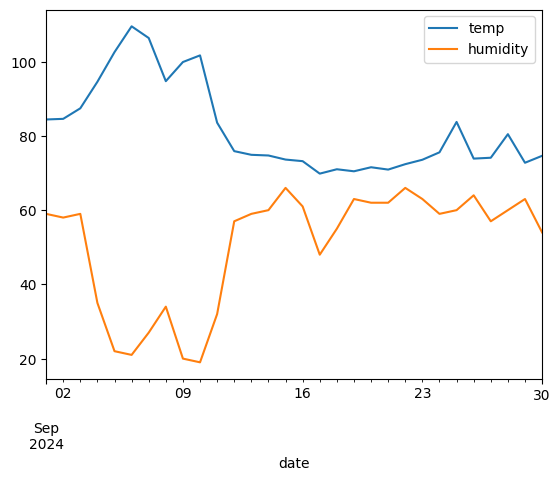

In [0]:
weather_df.set_index("date").plot.line()

In [0]:
import pandas as pd
sales_df=pd.read_csv("/Volumes/workspace/default/project_files/LA_Retail_Sales.csv")
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   store_id          750 non-null    object 
 1   store_name        750 non-null    object 
 2   product_category  750 non-null    object 
 3   date              750 non-null    object 
 4   Unit sales        745 non-null    float64
 5   DOLLAR SALES      743 non-null    float64
 6   store_zip         750 non-null    object 
 7   promotion_flag    750 non-null    bool   
dtypes: bool(1), float64(2), object(5)
memory usage: 41.9+ KB


In [0]:
sales_df.columns=sales_df.columns.str.lower().str.replace(" ","_")
sales_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   store_id          750 non-null    object 
 1   store_name        750 non-null    object 
 2   product_category  750 non-null    object 
 3   date              750 non-null    object 
 4   unit_sales        745 non-null    float64
 5   dollar_sales      743 non-null    float64
 6   store_zip         750 non-null    object 
 7   promotion_flag    750 non-null    bool   
dtypes: bool(1), float64(2), object(5)
memory usage: 41.9+ KB


In [0]:
sales_df.query("unit_sales.isna()")
missing_unit_indices=sales_df.query("unit_sales.isna()").index
sales_df["unit_sales"]=sales_df["unit_sales"].fillna(0)
sales_df.iloc[missing_unit_indices]
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   store_id          750 non-null    object 
 1   store_name        750 non-null    object 
 2   product_category  750 non-null    object 
 3   date              750 non-null    object 
 4   unit_sales        750 non-null    float64
 5   dollar_sales      743 non-null    float64
 6   store_zip         750 non-null    object 
 7   promotion_flag    750 non-null    bool   
dtypes: bool(1), float64(2), object(5)
memory usage: 41.9+ KB


In [0]:
sales_df=sales_df.dropna(subset=["unit_sales","dollar_sales"])
sales_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 743 entries, 0 to 749
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   store_id          743 non-null    object 
 1   store_name        743 non-null    object 
 2   product_category  743 non-null    object 
 3   date              743 non-null    object 
 4   unit_sales        743 non-null    float64
 5   dollar_sales      743 non-null    float64
 6   store_zip         743 non-null    object 
 7   promotion_flag    743 non-null    bool   
dtypes: bool(1), float64(2), object(5)
memory usage: 47.2+ KB


In [0]:
sales_df["rev_per_unit"]=(sales_df["dollar_sales"] / sales_df["unit_sales"]).round(2)
sales_df.head()

,store_id,store_name,product_category,date,unit_sales,dollar_sales,store_zip,promotion_flag,rev_per_unit
0,LA002,Store_2,Household,9/1/24,16.0,96.28,90004,True,6.02
1,LA001,Store_1,Beverages,9/1/24,14.0,86.63,90004,True,6.19
2,LA004,Store_4,Produce,9/15/24,18.0,298.26,90003,True,16.57
3,LA003,Store_3,Household,9/7/24,7.0,25.69,90001,True,3.67
4,LA008,Store_8,Beverages,9/18/24,25.0,85.46,90005,False,3.42


In [0]:
sales_df.store_zip.value_counts()
sales_df["store_zip"]=sales_df["store_zip"].str.replace("XX","00")
sales_df["store_zip"]

0      90004
1      90004
2      90003
3      90001
4      90005
       ...  
745    90005
746    90003
747    90000
748    90004
749    90003
Name: store_zip, Length: 743, dtype: object

In [0]:
sales_df["date"]=pd.to_datetime(sales_df["date"],format='mixed')
sales_df["promotion_flag"]=sales_df["promotion_flag"].astype("bool")
sales_df["unit_sales"]=sales_df["unit_sales"].astype("int")
sales_df["dollar_sales"]=sales_df["dollar_sales"].astype("float")
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 743 entries, 0 to 749
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   store_id          743 non-null    object        
 1   store_name        743 non-null    object        
 2   product_category  743 non-null    object        
 3   date              743 non-null    datetime64[ns]
 4   unit_sales        743 non-null    int64         
 5   dollar_sales      743 non-null    float64       
 6   store_zip         743 non-null    object        
 7   promotion_flag    743 non-null    bool          
 8   rev_per_unit      743 non-null    float64       
dtypes: bool(1), datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 53.0+ KB


In [0]:
sales_df.describe()

/databricks/python/lib/python3.12/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,date,unit_sales,dollar_sales,rev_per_unit
count,743,743.000000,743.000000,743.000
mean,2024-09-15 12:20:20.995962368,25.464334,279.496729,inf
min,2024-09-01 00:00:00,0.000000,5.330000,2.030
25%,2024-09-08 12:00:00,13.000000,104.920000,6.575
50%,2024-09-16 00:00:00,25.000000,224.690000,10.860
75%,2024-09-23 00:00:00,38.000000,407.095000,15.400
max,2024-09-30 00:00:00,50.000000,980.000000,inf
std,NaN,14.457709,217.190090,NaN


<Axes: ylabel='Frequency'>

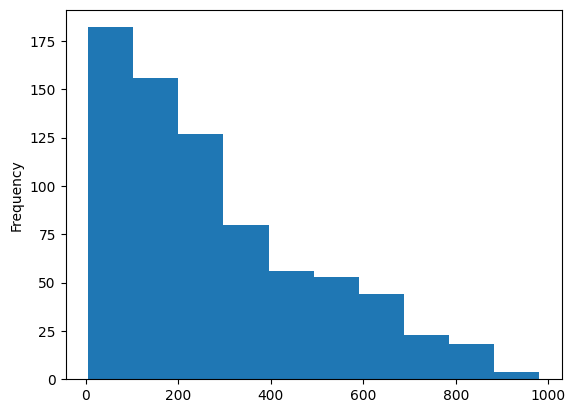

In [0]:
sales_df.dollar_sales.plot.hist()

<Axes: xlabel='dollar_sales', ylabel='Count'>

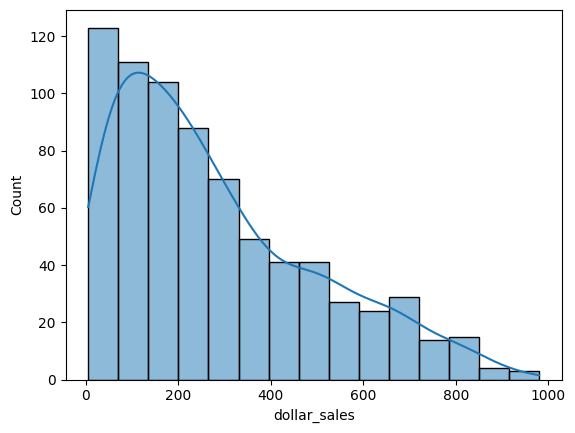

In [0]:
import seaborn as sns
sns.histplot(data=sales_df,x="dollar_sales",kde=True)


In [0]:
sales_df=sales_df.merge(weather_df[["date","temp"]],how="left",on="date")

In [0]:
sales_df.to_sql("Sales",if_exists="replace",index=False,con=conn)

743

In [0]:
pd.read_sql("select * from Sales WHERE temp>70",con=conn)

,store_id,store_name,product_category,date,unit_sales,dollar_sales,store_zip,promotion_flag,rev_per_unit,temp
0,LA002,Store_2,Household,2024-09-01 00:00:00,16,96.28,90004,1,6.02,84.43
1,LA001,Store_1,Beverages,2024-09-01 00:00:00,14,86.63,90004,1,6.19,84.43
2,LA004,Store_4,Produce,2024-09-15 00:00:00,18,298.26,90003,1,16.57,73.63
3,LA003,Store_3,Household,2024-09-07 00:00:00,7,25.69,90001,1,3.67,106.38
4,LA008,Store_8,Beverages,2024-09-18 00:00:00,25,85.46,90005,0,3.42,71.02
...,...,...,...,...,...,...,...,...,...,...
703,LA010,Store_10,Beverages,2024-09-24 00:00:00,46,790.99,90005,1,17.20,75.58
704,LA008,Store_8,Snacks,2024-09-14 00:00:00,23,375.40,90003,0,16.32,74.73
705,LA004,Store_4,Personal Care,2024-09-14 00:00:00,17,225.24,90000,0,13.25,74.73
706,LA009,Store_9,Snacks,2024-09-28 00:00:00,37,406.47,90004,0,10.99,80.47
